In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [124]:
pi = np.pi

sim = Sim(use_complex=True)


sim.add_param('sqrtka_ext', np.sqrt(10e6*2*pi)) # in MHz
sim.add_param('ka_int', 0e6*2*pi) # in MHz
sim.add_param('g4', 1e6 * 2 * np.pi)
sim.add_param('amplR', 20000)
sim.add_param('wa', 5.0e9*2*pi)
sim.add_paramsweep('ICphase', 0, 2*np.pi, 101)
sim.add_param('wR', 5.0e9*2*np.pi, is_excitation=True)
sim.add_param('rampR', 1e-9)
sim.add_param('startR', 10e-9)
sim.add_param('stopR', 40e-9)
sim.add_param('phaseR', 0)

sim.add_param('g3', 1e6 * 2 * np.pi)
sim.add_param('wG', 10.0e9*2*np.pi)
sim.add_param('amplG', 3)
sim.add_param('rampG', 1e-9)
sim.add_param('startG', 50e-9)
sim.add_param('stopG', 90e-9)
sim.add_param('phaseG', 0)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')
Gpulse = sim.make_pulse('wG', 'amplG', 'phaseG', 'startG', 'stopG', 'rampG')

sim.add_EOM('ain', Rpulse)
sim.add_EOM('s2', Gpulse)
sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a + 1j*g3*conjugate(a)*s2 - 1j*a*g4*abs(a)**2',IC_str='2')
sim.add_EOM('anoise', '-1j*wa*anoise + 1j*g3*conjugate(anoise)*s2 - 1j*anoise*g4*abs(a+anoise)**2', IC_str='0.5*exp(1j*ICphase)')

sim.set_solve_type('decimate')

sim.specify_time(20, 500, d_factor=1)

sim.validate(print_result=False)

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


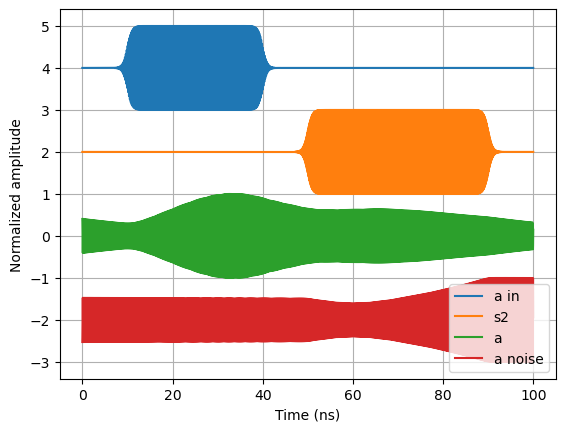

In [125]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:])+4,label='a in')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,label='s2')
plt.plot(t*1e9, x[4,:]/np.max(x[4,:]),label='a')
plt.plot(t*1e9, x[6,:]/np.max(x[6,:])-2,label='a noise')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [126]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:20<00:00, 483.81it/s]

 
...finished GPU solve!


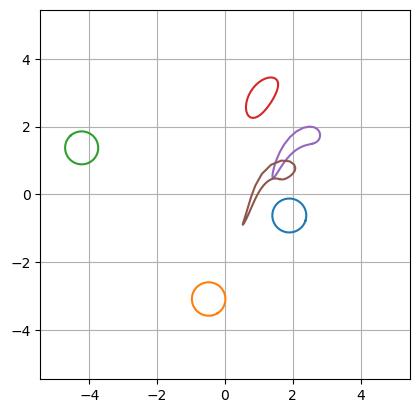

In [128]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[0,:]+1j*Qd[0,:]
a = Id[4,:]+1j*Qd[4,:]
anoise = Id[6,:]+1j*Qd[6,:]

ahat = a+anoise

i = 1
plt.plot(np.real(ahat[:,i]), np.imag(ahat[:,i]))

i = 100
plt.plot(np.real(ahat[:,i]), np.imag(ahat[:,i]))

i = 200
plt.plot(np.real(ahat[:,i]), np.imag(ahat[:,i]))

i = 300
plt.plot(np.real(ahat[:,i]), np.imag(ahat[:,i]))

i = 400
plt.plot(np.real(ahat[:,i]), np.imag(ahat[:,i]))

i = 499
plt.plot(np.real(ahat[:,i]), np.imag(ahat[:,i]))

LIM = np.max(np.abs(ahat))*1.0
plt.grid()
ax = plt.gca()
ax.set_aspect(1)
plt.xlim([-LIM,LIM])
plt.ylim([-LIM,LIM])
plt.show()